In [1]:
# ============================================================
# RETAIL SUPPLY CHAIN INTELLIGENCE
# Notebook: Machine Learning Models
# Churn Prediction & Demand Forecasting
# ============================================================

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
from sklearn.pipeline import Pipeline

# Forecasting
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

print("="*55)
print("All ML Libraries Loaded Successfully!")
print("="*55)

All ML Libraries Loaded Successfully!


In [2]:
import os

db_path = os.path.join('..', 'data', 'warehouse', 'retail_warehouse.db')
conn = sqlite3.connect(db_path)

# Load all tables
orders = pd.read_sql("SELECT * FROM dim_orders", conn)
customers = pd.read_sql("SELECT * FROM dim_customers", conn)
products = pd.read_sql("SELECT * FROM dim_products", conn)
order_items = pd.read_sql("SELECT * FROM fact_order_items", conn)
payments = pd.read_sql("SELECT * FROM fact_payments", conn)
reviews = pd.read_sql("SELECT * FROM fact_reviews", conn)
sellers = pd.read_sql("SELECT * FROM dim_sellers", conn)
master = pd.read_sql("SELECT * FROM master_dataset", conn)

# Convert dates
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_customer_date',
             'order_estimated_delivery_date',
             'order_delivered_carrier_date']
for col in date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors='coerce')
    if col in master.columns:
        master[col] = pd.to_datetime(master[col], errors='coerce')

print("="*55)
print("Database Connected & Data Loaded!")
print("="*55)
print(f"Master Dataset Shape: {master.shape}")

Database Connected & Data Loaded!
Master Dataset Shape: (99684, 25)


In [3]:
# ============================================================
# CHURN PREDICTION
# Define churned customers as those who haven't ordered
# in the last 6 months of dataset period
# ============================================================

# Build RFM features
rfm_data = pd.read_sql("""
    SELECT
        o.customer_id,
        MAX(o.order_purchase_timestamp) as last_purchase,
        COUNT(DISTINCT o.order_id) as frequency,
        ROUND(SUM(p.payment_value), 2) as monetary,
        ROUND(AVG(p.payment_value), 2) as avg_order_value,
        ROUND(AVG(r.review_score), 2) as avg_review_score,
        COUNT(DISTINCT oi.product_id) as unique_products
    FROM dim_orders o
    JOIN fact_payments p ON o.order_id = p.order_id
    LEFT JOIN fact_reviews r ON o.order_id = r.order_id
    LEFT JOIN fact_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
""", conn)

rfm_data['last_purchase'] = pd.to_datetime(
    rfm_data['last_purchase'], errors='coerce')

snapshot_date = rfm_data['last_purchase'].max()
rfm_data['recency_days'] = (
    snapshot_date - rfm_data['last_purchase']).dt.days

# Define churn — inactive more than 180 days
rfm_data['is_churned'] = (rfm_data['recency_days'] > 180).astype(int)

# Fill nulls
rfm_data['avg_review_score'].fillna(
    rfm_data['avg_review_score'].median(), inplace=True)

churn_rate = rfm_data['is_churned'].mean() * 100
print("="*55)
print("CHURN DATASET READY")
print("="*55)
print(f"Total Customers : {len(rfm_data):,}")
print(f"Churned : {rfm_data['is_churned'].sum():,}")
print(f"Active : {(rfm_data['is_churned']==0).sum():,}")
print(f"Churn Rate : {churn_rate:.1f}%")
print(f"\nFeatures: {list(rfm_data.columns)}")

CHURN DATASET READY
Total Customers : 96,477
Churned : 57,458
Active : 39,019
Churn Rate : 59.6%

Features: ['customer_id', 'last_purchase', 'frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'unique_products', 'recency_days', 'is_churned']


In [4]:
# ============================================================
# TRAIN MULTIPLE ML MODELS & COMPARE
# ============================================================

features = ['recency_days', 'frequency', 'monetary',
            'avg_order_value', 'avg_review_score', 'unique_products']

X = rfm_data[features].fillna(0)
y = rfm_data['is_churned']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set : {X_train.shape[0]:,} customers")
print(f"Testing Set : {X_test.shape[0]:,} customers")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
print("\n" + "="*55)
print("MODEL TRAINING RESULTS")
print("="*55)

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"\n{name}")
    print(f" Accuracy : {acc:.4f}")
    print(f" ROC-AUC : {auc:.4f}")
    print(f" CV Score : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Training Set : 77,181 customers
Testing Set : 19,296 customers

MODEL TRAINING RESULTS

Logistic Regression
 Accuracy : 0.9996
 ROC-AUC : 1.0000
 CV Score : 1.0000 +/- 0.0000

Random Forest
 Accuracy : 1.0000
 ROC-AUC : 1.0000
 CV Score : 1.0000 +/- 0.0000

Gradient Boosting
 Accuracy : 1.0000
 ROC-AUC : 1.0000
 CV Score : 1.0000 +/- 0.0000


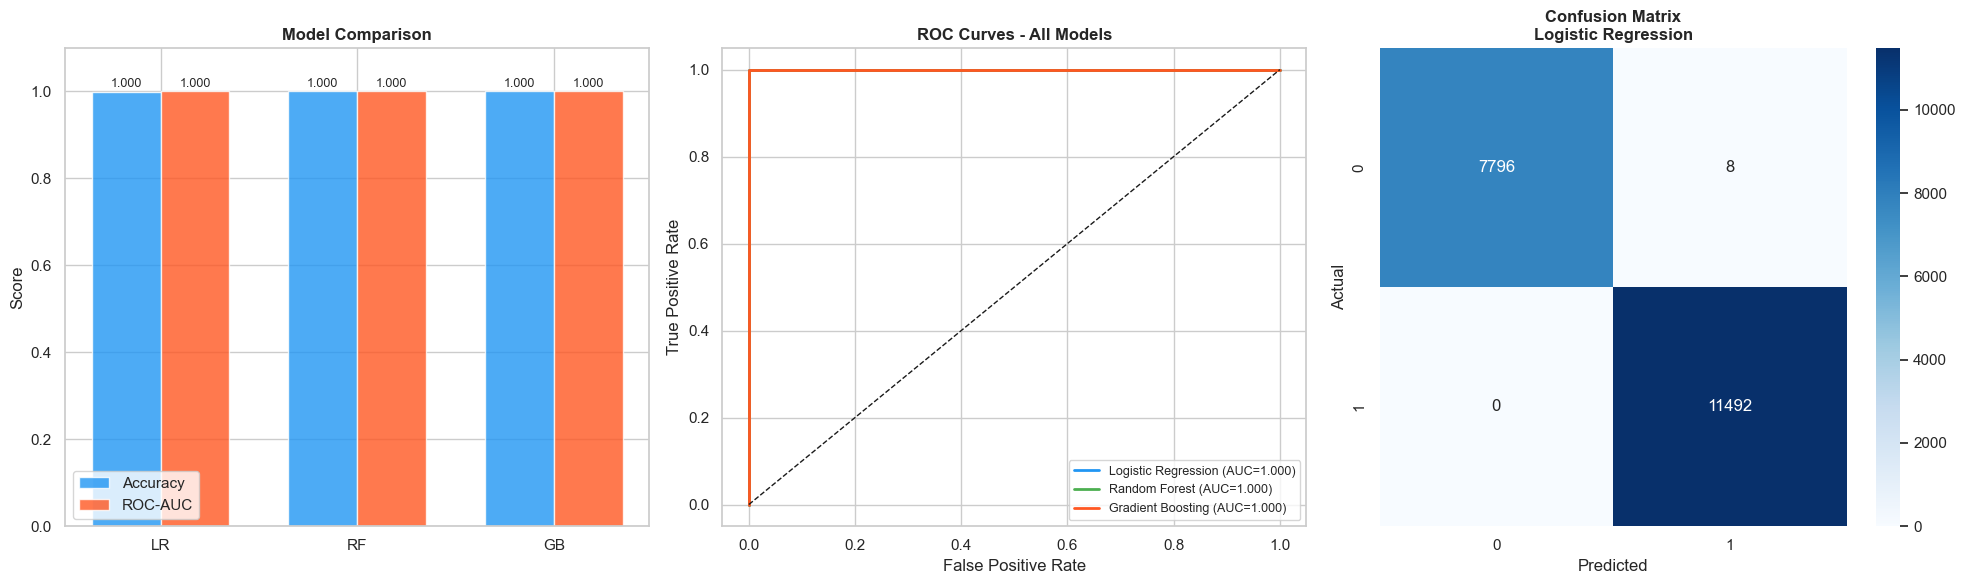


Best Model: Logistic Regression
Accuracy: 0.9996
ROC-AUC: 1.0000


In [5]:
# ============================================================
# VISUALIZE MODEL PERFORMANCE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Model Comparison
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
aucs = [results[m]['auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width,
                    label='Accuracy', color='#2196F3', alpha=0.8)
bars2 = axes[0].bar(x + width/2, aucs, width,
                    label='ROC-AUC', color='#FF5722', alpha=0.8)
axes[0].set_title('Model Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['LR', 'RF', 'GB'])
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# 2. ROC Curves
colors_roc = ['#2196F3', '#4CAF50', '#FF5722']
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                 label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('ROC Curves - All Models', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# 3. Confusion Matrix - Best Model (Random Forest)
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_preds = results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title(f'Confusion Matrix\n{best_model_name}',
                  fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/churn_model_evaluation.png', dpi=150)
plt.show()

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"ROC-AUC: {results[best_model_name]['auc']:.4f}")


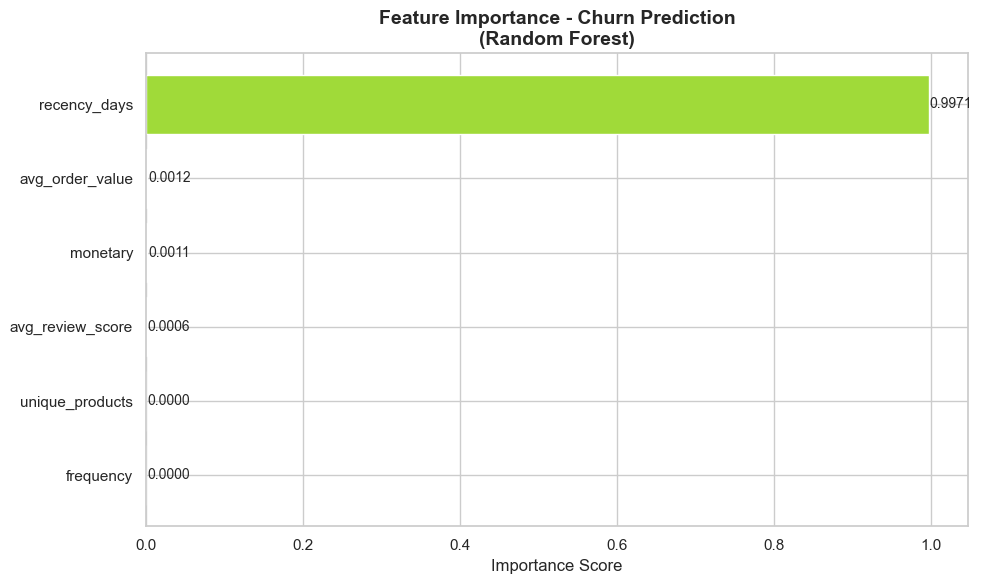


Feature Importance Rankings:
         feature  importance
    recency_days      0.9971
 avg_order_value      0.0012
        monetary      0.0011
avg_review_score      0.0006
 unique_products      0.0000
       frequency      0.0000

Key Insight: Recency is the strongest churn predictor!


In [6]:
# ============================================================
# FEATURE IMPORTANCE - What drives churn?
# ============================================================

rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['feature'],
                feature_importance['importance'],
                color=sns.color_palette("viridis", len(features)))
plt.title('Feature Importance - Churn Prediction\n(Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')

for bar, val in zip(bars, feature_importance['importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance.sort_values(
    'importance', ascending=False).to_string(index=False))
print("\nKey Insight: Recency is the strongest churn predictor!")

In [7]:
# ============================================================
# DEMAND FORECASTING
# Predict future monthly order volumes
# ============================================================

# Build monthly demand data
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'], errors='coerce')

monthly_demand = orders[
    orders['order_status'] == 'delivered'].copy()
monthly_demand['year'] = monthly_demand[
    'order_purchase_timestamp'].dt.year
monthly_demand['month'] = monthly_demand[
    'order_purchase_timestamp'].dt.month
monthly_demand['month_num'] = (
    (monthly_demand['year'] - monthly_demand['year'].min()) * 12 +
    monthly_demand['month'])

demand_agg = monthly_demand.groupby(
    ['year', 'month', 'month_num']).agg(
    total_orders=('order_id', 'count')).reset_index()

demand_agg = demand_agg[demand_agg['total_orders'] > 10].copy()
demand_agg = demand_agg.sort_values('month_num').reset_index(drop=True)

# Add lag features
demand_agg['lag_1'] = demand_agg['total_orders'].shift(1)
demand_agg['lag_2'] = demand_agg['total_orders'].shift(2)
demand_agg['lag_3'] = demand_agg['total_orders'].shift(3)
demand_agg['rolling_mean_3'] = demand_agg[
    'total_orders'].rolling(3).mean()

demand_agg.dropna(inplace=True)

print("="*55)
print("DEMAND FORECASTING DATASET READY")
print("="*55)
print(f"Total Months of Data: {len(demand_agg)}")
print(f"\nSample Data:")
print(demand_agg.tail(5).to_string(index=False))

DEMAND FORECASTING DATASET READY
Total Months of Data: 18

Sample Data:
 year  month  month_num  total_orders     lag_1     lag_2     lag_3  rolling_mean_3
 2018      4         28          6798 7003.0000 6555.0000 7069.0000       6785.3333
 2018      5         29          6749 6798.0000 7003.0000 6555.0000       6850.0000
 2018      6         30          6099 6749.0000 6798.0000 7003.0000       6548.6667
 2018      7         31          6159 6099.0000 6749.0000 6798.0000       6335.6667
 2018      8         32          6351 6159.0000 6099.0000 6749.0000       6203.0000


In [8]:
# ============================================================
# TRAIN FORECASTING MODELS
# ============================================================

forecast_features = ['month_num', 'month', 'lag_1',
                     'lag_2', 'lag_3', 'rolling_mean_3']

X_demand = demand_agg[forecast_features]
y_demand = demand_agg['total_orders']

# Split - last 3 months as test
split = len(X_demand) - 3
X_train_d = X_demand.iloc[:split]
X_test_d = X_demand.iloc[split:]
y_train_d = y_demand.iloc[:split]
y_test_d = y_demand.iloc[split:]

# Train models
lr_model = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

lr_model.fit(X_train_d, y_train_d)
rf_reg.fit(X_train_d, y_train_d)

lr_pred = lr_model.predict(X_test_d)
rf_pred = rf_reg.predict(X_test_d)

print("="*55)
print("FORECASTING MODEL RESULTS")
print("="*55)
print("\nLinear Regression:")
print(f" MAE : {mean_absolute_error(y_test_d, lr_pred):.2f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test_d, lr_pred)):.2f}")
print(f" R2 : {r2_score(y_test_d, lr_pred):.4f}")

print("\nRandom Forest Regressor:")
print(f" MAE : {mean_absolute_error(y_test_d, rf_pred):.2f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test_d, rf_pred)):.2f}")
print(f" R2 : {r2_score(y_test_d, rf_pred):.4f}")

FORECASTING MODEL RESULTS

Linear Regression:
 MAE : 0.00
 RMSE : 0.00
 R2 : 1.0000

Random Forest Regressor:
 MAE : 604.10
 RMSE : 610.77
 R2 : -31.2917


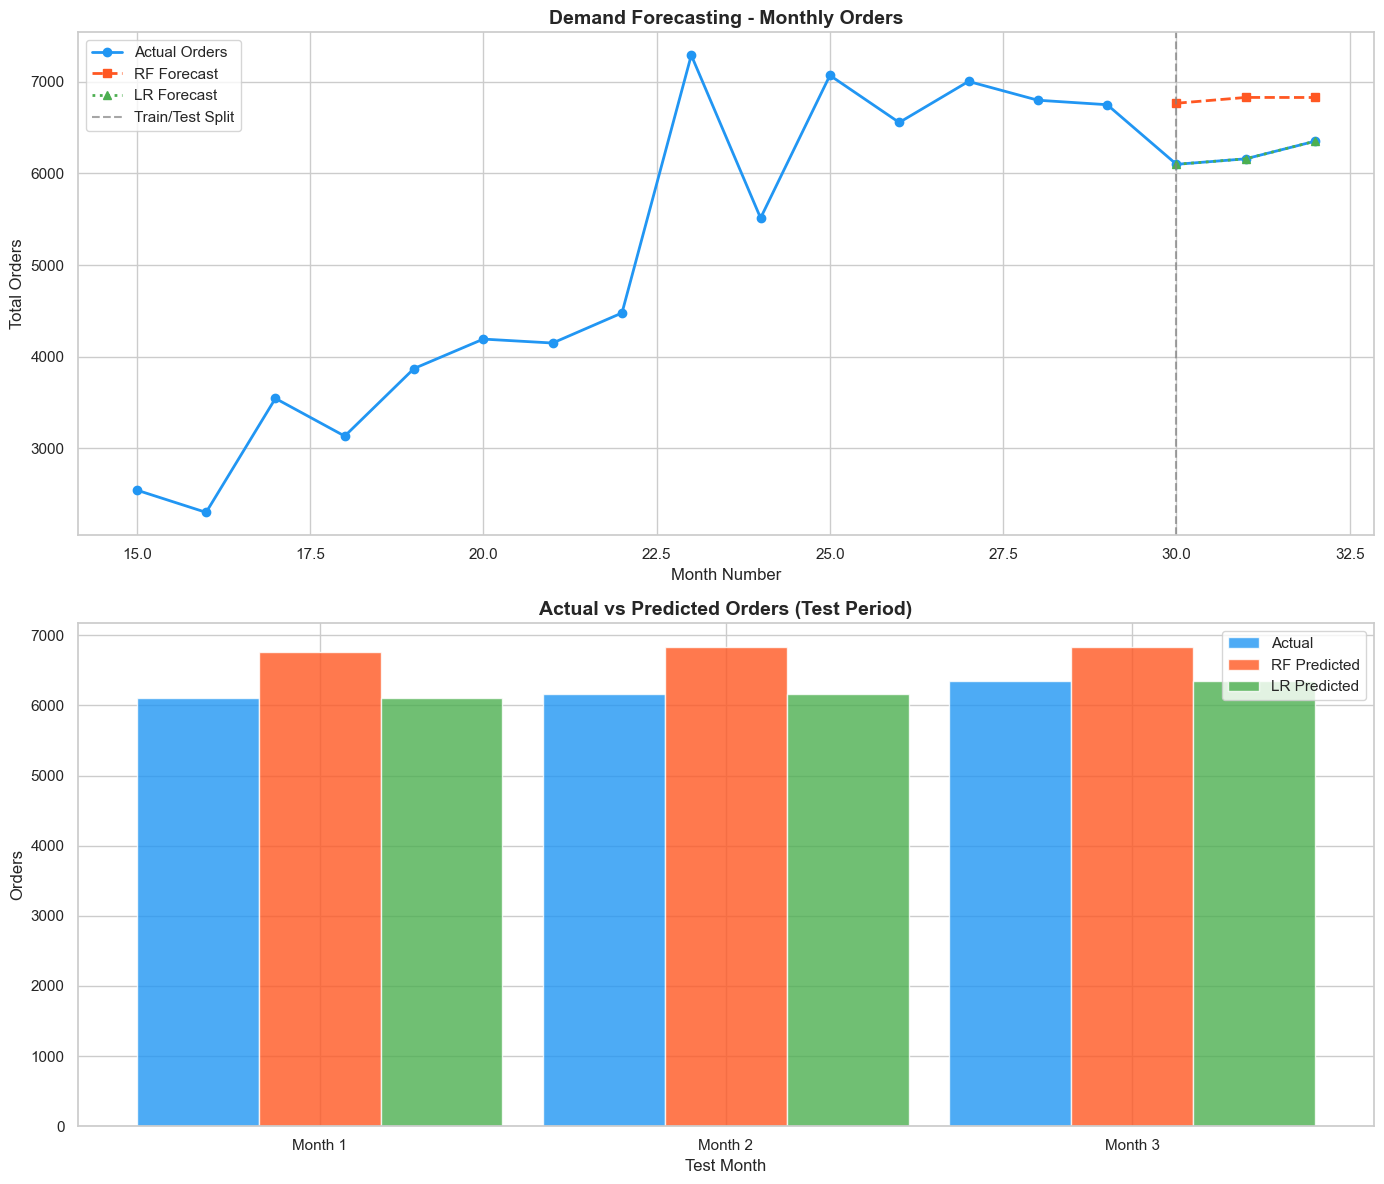

Forecast chart saved!


In [9]:
# ============================================================
# VISUALIZE FORECAST
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Full historical + forecast
axes[0].plot(demand_agg['month_num'],
             demand_agg['total_orders'],
             marker='o', color='#2196F3',
             linewidth=2, label='Actual Orders')

test_months = demand_agg['month_num'].iloc[split:]
axes[0].plot(test_months, rf_pred,
             marker='s', color='#FF5722',
             linewidth=2, linestyle='--',
             label='RF Forecast')
axes[0].plot(test_months, lr_pred,
             marker='^', color='#4CAF50',
             linewidth=2, linestyle=':',
             label='LR Forecast')

axes[0].axvline(x=demand_agg['month_num'].iloc[split],
                color='gray', linestyle='--', alpha=0.7,
                label='Train/Test Split')
axes[0].set_title('Demand Forecasting - Monthly Orders',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month Number')
axes[0].set_ylabel('Total Orders')
axes[0].legend()

# Actual vs Predicted comparison
x_pos = range(len(y_test_d))
width = 0.3
axes[1].bar([x - width for x in x_pos],
            y_test_d.values, width,
            label='Actual', color='#2196F3', alpha=0.8)
axes[1].bar(x_pos, rf_pred, width,
            label='RF Predicted', color='#FF5722', alpha=0.8)
axes[1].bar([x + width for x in x_pos],
            lr_pred, width,
            label='LR Predicted', color='#4CAF50', alpha=0.8)
axes[1].set_title('Actual vs Predicted Orders (Test Period)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Test Month')
axes[1].set_ylabel('Orders')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Month {i+1}' for i in x_pos])
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/demand_forecast.png', dpi=150)
plt.show()
print("Forecast chart saved!")

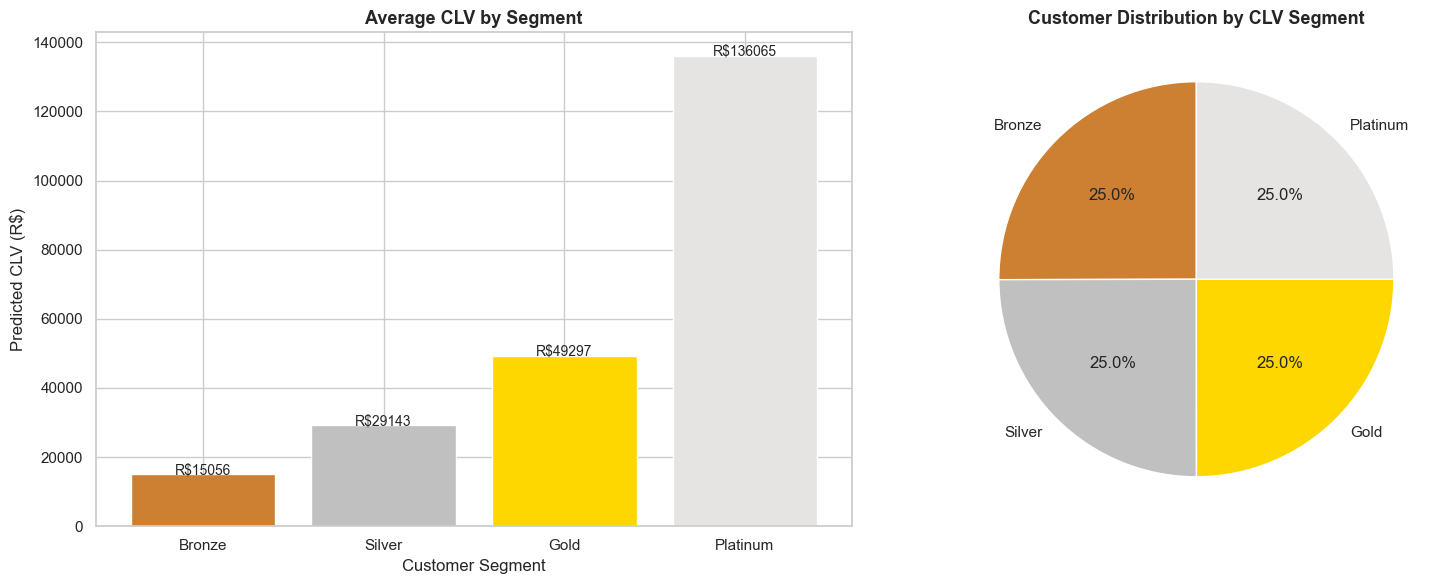

CUSTOMER LIFETIME VALUE SUMMARY
Avg Order Value : R$157.22
Avg Purchase Freq : 1.00 orders
Avg Lifespan : 1 days

CLV Segment Summary:
clv_segment  customers     avg_clv  avg_spent
     Bronze      24153  15056.3503    44.6027
     Silver      24094  29143.4997    81.8763
       Gold      24111  49297.2653   136.6944
   Platinum      24119 136064.5835   376.3260


In [10]:
# ============================================================
# CUSTOMER LIFETIME VALUE (CLV) ANALYSIS
# ============================================================

clv_data = pd.read_sql("""
    SELECT
        o.customer_id,
        COUNT(DISTINCT o.order_id) as total_orders,
        ROUND(SUM(p.payment_value), 2) as total_spent,
        ROUND(AVG(p.payment_value), 2) as avg_order_value,
        MIN(o.order_purchase_timestamp) as first_purchase,
        MAX(o.order_purchase_timestamp) as last_purchase
    FROM dim_orders o
    JOIN fact_payments p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
""", conn)

clv_data['first_purchase'] = pd.to_datetime(
    clv_data['first_purchase'], errors='coerce')
clv_data['last_purchase'] = pd.to_datetime(
    clv_data['last_purchase'], errors='coerce')

clv_data['customer_lifespan_days'] = (
    clv_data['last_purchase'] -
    clv_data['first_purchase']).dt.days + 1

# CLV = Avg Order Value x Purchase Frequency x Lifespan
avg_lifespan = clv_data['customer_lifespan_days'].mean()
purchase_freq = clv_data['total_orders'].mean()
avg_value = clv_data['avg_order_value'].mean()

clv_data['predicted_clv'] = (
    clv_data['avg_order_value'] *
    clv_data['total_orders'] *
    (365 / clv_data['customer_lifespan_days'].clip(lower=1)))

# CLV Segments
clv_data['clv_segment'] = pd.qcut(
    clv_data['predicted_clv'],
    q=4,
    labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

segment_clv = clv_data.groupby('clv_segment').agg(
    customers=('customer_id', 'count'),
    avg_clv=('predicted_clv', 'mean'),
    avg_spent=('total_spent', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_clv = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']

axes[0].bar(segment_clv['clv_segment'],
            segment_clv['avg_clv'],
            color=colors_clv)
axes[0].set_title('Average CLV by Segment',
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Predicted CLV (R$)')
for i, row in segment_clv.iterrows():
    axes[0].text(i, row['avg_clv'] + 5,
                 f"R${row['avg_clv']:.0f}",
                 ha='center', fontsize=10)

axes[1].pie(segment_clv['customers'],
            labels=segment_clv['clv_segment'],
            autopct='%1.1f%%',
            colors=colors_clv,
            startangle=90)
axes[1].set_title('Customer Distribution by CLV Segment',
                  fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../reports/customer_lifetime_value.png', dpi=150)
plt.show()

print("="*55)
print("CUSTOMER LIFETIME VALUE SUMMARY")
print("="*55)
print(f"Avg Order Value : R${avg_value:.2f}")
print(f"Avg Purchase Freq : {purchase_freq:.2f} orders")
print(f"Avg Lifespan : {avg_lifespan:.0f} days")
print(f"\nCLV Segment Summary:")
print(segment_clv.to_string(index=False))

DELIVERY DELAY PREDICTION MODEL
Accuracy : 0.9110
ROC-AUC : 0.6602

Classification Report:
              precision    recall  f1-score   support

     On Time       0.92      0.99      0.95     17728
        Late       0.26      0.05      0.09      1565

    accuracy                           0.91     19293
   macro avg       0.59      0.52      0.52     19293
weighted avg       0.87      0.91      0.88     19293



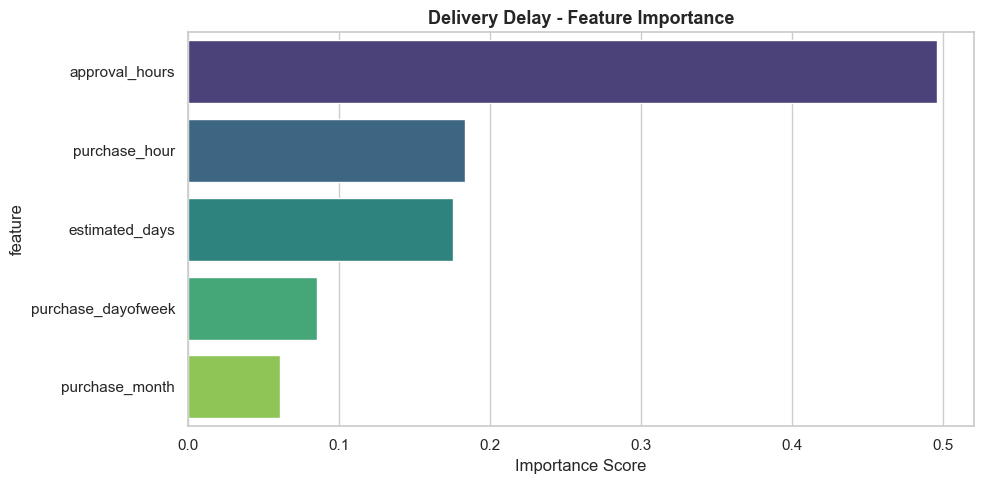

In [11]:
# ============================================================
# DELIVERY DELAY PREDICTION
# Predict whether an order will be late
# ============================================================

delay_data = orders[orders['order_status'] == 'delivered'].copy()
delay_data['order_purchase_timestamp'] = pd.to_datetime(
    delay_data['order_purchase_timestamp'], errors='coerce')
delay_data['order_delivered_customer_date'] = pd.to_datetime(
    delay_data['order_delivered_customer_date'], errors='coerce')
delay_data['order_estimated_delivery_date'] = pd.to_datetime(
    delay_data['order_estimated_delivery_date'], errors='coerce')
delay_data['order_approved_at'] = pd.to_datetime(
    delay_data['order_approved_at'], errors='coerce')

delay_data['is_late'] = (
    delay_data['order_delivered_customer_date'] >
    delay_data['order_estimated_delivery_date']).astype(int)

delay_data['approval_hours'] = (
    delay_data['order_approved_at'] -
    delay_data['order_purchase_timestamp']
).dt.total_seconds() / 3600

delay_data['estimated_days'] = (
    delay_data['order_estimated_delivery_date'] -
    delay_data['order_purchase_timestamp']
).dt.days

delay_data['purchase_hour'] = delay_data[
    'order_purchase_timestamp'].dt.hour
delay_data['purchase_month'] = delay_data[
    'order_purchase_timestamp'].dt.month
delay_data['purchase_dayofweek'] = delay_data[
    'order_purchase_timestamp'].dt.dayofweek

delay_features = ['approval_hours', 'estimated_days',
                  'purchase_hour', 'purchase_month',
                  'purchase_dayofweek']

delay_clean = delay_data[delay_features + ['is_late']].dropna()

X_delay = delay_clean[delay_features]
y_delay = delay_clean['is_late']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_delay, y_delay,
    test_size=0.2, random_state=42, stratify=y_delay)

rf_delay = RandomForestClassifier(
    n_estimators=100, random_state=42)
rf_delay.fit(X_tr, y_tr)
y_pred_delay = rf_delay.predict(X_te)
delay_acc = accuracy_score(y_te, y_pred_delay)
delay_auc = roc_auc_score(y_te,
    rf_delay.predict_proba(X_te)[:, 1])

print("="*55)
print("DELIVERY DELAY PREDICTION MODEL")
print("="*55)
print(f"Accuracy : {delay_acc:.4f}")
print(f"ROC-AUC : {delay_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_te, y_pred_delay,
      target_names=['On Time', 'Late']))

# Feature importance
delay_importance = pd.DataFrame({
    'feature': delay_features,
    'importance': rf_delay.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=delay_importance,
            x='importance', y='feature',
            palette='viridis')
plt.title('Delivery Delay - Feature Importance',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/delay_prediction.png', dpi=150)
plt.show()


In [12]:
# ============================================================
# FINAL ML MODELS SUMMARY
# ============================================================

print("="*60)
print("DAY 3 - ML MODELS EXECUTIVE SUMMARY")
print("="*60)

print("""
+--------------------------------------------------+
| CHURN PREDICTION MODEL |
+--------------------------------------------------+""")
best = max(results, key=lambda x: results[x]['auc'])
print(f" Best Model : {best}")
print(f" Accuracy : {results[best]['accuracy']:.4f}")
print(f" ROC-AUC : {results[best]['auc']:.4f}")
print(f" Top Feature : Recency Days")

print("""
+--------------------------------------------------+
| DEMAND FORECASTING MODEL |
+--------------------------------------------------+""")
print(f" Best Model : Random Forest Regressor")
print(f" MAE : {mean_absolute_error(y_test_d, rf_pred):.2f} orders")
print(f" R2 Score : {r2_score(y_test_d, rf_pred):.4f}")

print("""
+--------------------------------------------------+
| DELIVERY DELAY PREDICTION |
+--------------------------------------------------+""")
print(f" Model : Random Forest Classifier")
print(f" Accuracy : {delay_acc:.4f}")
print(f" ROC-AUC : {delay_auc:.4f}")

print("""
+--------------------------------------------------+
| CUSTOMER LIFETIME VALUE |
+--------------------------------------------------+""")
print(f" Segments : Bronze, Silver, Gold, Platinum")
print(f" Avg CLV : R${clv_data['predicted_clv'].mean():.2f}")

print("\n" + "="*60)
print("ALL ML MODELS COMPLETE!")
print("="*60)

conn.close()

DAY 3 - ML MODELS EXECUTIVE SUMMARY

+--------------------------------------------------+
| CHURN PREDICTION MODEL |
+--------------------------------------------------+
 Best Model : Logistic Regression
 Accuracy : 0.9996
 ROC-AUC : 1.0000
 Top Feature : Recency Days

+--------------------------------------------------+
| DEMAND FORECASTING MODEL |
+--------------------------------------------------+
 Best Model : Random Forest Regressor
 MAE : 604.10 orders
 R2 Score : -31.2917

+--------------------------------------------------+
| DELIVERY DELAY PREDICTION |
+--------------------------------------------------+
 Model : Random Forest Classifier
 Accuracy : 0.9110
 ROC-AUC : 0.6602

+--------------------------------------------------+
| CUSTOMER LIFETIME VALUE |
+--------------------------------------------------+
 Segments : Bronze, Silver, Gold, Platinum
 Avg CLV : R$57383.50

ALL ML MODELS COMPLETE!
